# Package Damage Model Training Notebook
This notebook trains and evaluates a binary classifier for package condition.

Workflow used in this notebook:
1. Load image paths for damaged and intact classes.
2. Build train, validation, and test splits.
3. Create TensorFlow data generators with augmentation for training.
4. Define and train the ResNet34 model.
5. Evaluate with confusion matrix, ROC, and precision recall curves.
6. Visualize filters and feature maps for model understanding.

In [ ]:
# Step 1: Import required libraries for file handling and tabular operations.
import os
import pandas as pd

# Preparing the dataset

In [ ]:
# Step 2: Set dataset folder paths for each class.
# Class mapping used in this notebook: damaged = 1, intact = 0.
damaged_images_path = "/kaggle/input/damaged-package-detection/dataset/damaged"
intact_images_path = "/kaggle/input/damaged-package-detection/dataset/intact"

In [ ]:
# Step 3: Build a list of image file paths with labels.
# Each entry format: (image_path, class_label).
damaged = []
intact = []

for image in os.listdir(damaged_images_path):
    damaged.append((os.path.join(damaged_images_path, image), 1))

for image in os.listdir(intact_images_path):
    intact.append((os.path.join(intact_images_path, image), 0))

In [4]:
len(damaged), len(intact)

(6476, 2028)

In [5]:
damaged_df = pd.DataFrame(damaged, columns = ['img_path', 'class'])
damaged_df['class'] = damaged_df['class'].astype('str')

intact_df = pd.DataFrame(intact, columns = ['img_path', 'class'])
intact_df['class'] = intact_df['class'].astype('str')

In [ ]:
# Step 4: Shuffle each class and split into train, validation, and test sets.
# Split ratio per class: 70% train, 15% validation, 15% test.
from sklearn.model_selection import train_test_split

damaged_df_small = damaged_df.sample(frac=1, random_state=7)
intact_df_small = intact_df.sample(frac=1, random_state=7)

damaged_train_df, damaged_val_df = train_test_split(damaged_df_small, test_size=0.3, random_state=7)
damaged_val_df, damaged_test_df = train_test_split(damaged_val_df, test_size=0.5, random_state=7)

intact_train_df, intact_val_df = train_test_split(intact_df_small, test_size=0.3, random_state=7)
intact_val_df, intact_test_df = train_test_split(intact_val_df, test_size=0.5, random_state=7)

In [7]:
# create the final dataset for train, validation and test that contains both damaged and intact images in equal proportions
train_df = pd.concat([damaged_train_df, intact_train_df])
val_df = pd.concat([damaged_val_df, intact_val_df])
test_df = pd.concat([damaged_test_df, intact_test_df])

# shuffle the dataset
train_df = train_df.sample(frac = 1)
val_df = val_df.sample(frac = 1)
test_df = test_df.sample(frac = 1)

In [8]:
train_df.head()

,img_path,class
3703,/kaggle/input/damaged-package-detection/datase...,1
1456,/kaggle/input/damaged-package-detection/datase...,1
5121,/kaggle/input/damaged-package-detection/datase...,1
633,/kaggle/input/damaged-package-detection/datase...,1
674,/kaggle/input/damaged-package-detection/datase...,1


In [9]:
train_df['class'].value_counts()

1    4533
0    1419
Name: class, dtype: int64

In [10]:
test_df['class'].value_counts()

1    972
0    305
Name: class, dtype: int64

In [11]:
val_df['class'].value_counts()

1    971
0    304
Name: class, dtype: int64

In [12]:
len(train_df), len(val_df), len(test_df)

(5952, 1275, 1277)

In [13]:
import tensorflow as tf

In [14]:
img_width = 256
img_height = 256
n_channels = 1
batch_size = 16
class_names = ['intact', 'damaged']
num_classes = 2

In [15]:
# data generator for training dataset, performs data augmentations
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    horizontal_flip=True,
    vertical_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    fill_mode='nearest'
)

# data generator for validation and testing dataset, here no data augmentation is performed
val_test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
)

In [ ]:
# Step 5: Create TensorFlow generators for train, validation, and test datasets.
# Training generator uses augmentation. Validation and test generators only rescale pixels.
train_generator = train_datagen.flow_from_dataframe(
    dataframe = train_df,
    x_col = 'img_path',
    y_col = 'class',
    target_size = (img_width, img_height),
    color_mode = 'rgb',
    batch_size = batch_size,
    class_mode = 'categorical',
    shuffle = True,
    seed = 7
)

valid_generator = val_test_datagen.flow_from_dataframe(
    dataframe = val_df,
    x_col = 'img_path',
    y_col = 'class',
    target_size = (img_width, img_height),
    color_mode = 'rgb',
    batch_size = batch_size,
    class_mode = 'categorical',
    shuffle = True,
    seed = 7
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe = test_df,
    x_col = 'img_path',
    y_col = 'class',
    target_size = (img_width, img_height),
    color_mode = 'rgb',
    batch_size = batch_size,
    class_mode = 'categorical',
    shuffle = True,
    seed = 7
)

Found 5924 validated image filenames belonging to 2 classes.


/opt/conda/lib/python3.7/site-packages/keras/preprocessing/image.py:1139: UserWarning: Found 28 invalid image filename(s) in x_col="img_path". These filename(s) will be ignored.
  "These filename(s) will be ignored.".format(n_invalid, x_col)


Found 1269 validated image filenames belonging to 2 classes.


/opt/conda/lib/python3.7/site-packages/keras/preprocessing/image.py:1139: UserWarning: Found 6 invalid image filename(s) in x_col="img_path". These filename(s) will be ignored.
  "These filename(s) will be ignored.".format(n_invalid, x_col)


Found 1264 validated image filenames belonging to 2 classes.


/opt/conda/lib/python3.7/site-packages/keras/preprocessing/image.py:1139: UserWarning: Found 13 invalid image filename(s) in x_col="img_path". These filename(s) will be ignored.
  "These filename(s) will be ignored.".format(n_invalid, x_col)


In [17]:
import os

def create_model_checkpoint(model_name, save_path="model_checkpoints"):
  return tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(save_path, model_name),
    verbose=0,
    save_best_only=True,
    monitor = 'val_accuracy'
  )

# Building a model with ResNet-34 Architecture

![ResNet-32 Architecture](https://editor.analyticsvidhya.com/uploads/38371XTo6Q.png)

In [18]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [19]:
def identity_block(x, filter):
    # copy tensor to variable called x_skip
    x_skip = x
    # Layer 1
    x = tf.keras.layers.Conv2D(filter, (3,3), padding = 'same')(x)
    x = tf.keras.layers.BatchNormalization(axis=3)(x)
    x = tf.keras.layers.Activation('relu')(x)
    # Layer 2
    x = tf.keras.layers.Conv2D(filter, (3,3), padding = 'same')(x)
    x = tf.keras.layers.BatchNormalization(axis=3)(x)
    # Add Residue
    x = tf.keras.layers.Add()([x, x_skip])     
    x = tf.keras.layers.Activation('relu')(x)
    return x

In [20]:
def convolutional_block(x, filter):
    # copy tensor to variable called x_skip
    x_skip = x
    # Layer 1
    x = tf.keras.layers.Conv2D(filter, (3,3), padding = 'same', strides = (2,2))(x)
    x = tf.keras.layers.BatchNormalization(axis=3)(x)
    x = tf.keras.layers.Activation('relu')(x)
    # Layer 2
    x = tf.keras.layers.Conv2D(filter, (3,3), padding = 'same')(x)
    x = tf.keras.layers.BatchNormalization(axis=3)(x)
    # Processing Residue with conv(1,1)
    x_skip = tf.keras.layers.Conv2D(filter, (1,1), strides = (2,2))(x_skip)
    # Add Residue
    x = tf.keras.layers.Add()([x, x_skip])     
    x = tf.keras.layers.Activation('relu')(x)
    return x

In [21]:
def ResNet34(shape = (32, 32, 3), classes = 10):
    # Step 1 (Setup Input Layer)
    x_input = tf.keras.layers.Input(shape)
    x = tf.keras.layers.ZeroPadding2D((3, 3))(x_input)
    # Step 2 (Initial Conv layer along with maxPool)
    x = tf.keras.layers.Conv2D(64, kernel_size=7, strides=2, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPool2D(pool_size=3, strides=2, padding='same')(x)
    # Define size of sub-blocks and initial filter size
    block_layers = [3, 4, 6, 3]
    filter_size = 64
    # Step 3 Add the Resnet Blocks
    for i in range(4):
        if i == 0:
            # For sub-block 1 Residual/Convolutional block not needed
            for j in range(block_layers[i]):
                x = identity_block(x, filter_size)
        else:
            # One Residual/Convolutional Block followed by Identity blocks
            # The filter size will go on increasing by a factor of 2
            filter_size = filter_size*2
            x = convolutional_block(x, filter_size)
            for j in range(block_layers[i] - 1):
                x = identity_block(x, filter_size)
    # Step 4 End Dense Network
    x = tf.keras.layers.AveragePooling2D((2,2), padding = 'same')(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(512, activation = 'relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(classes, activation = 'softmax')(x)
    model = tf.keras.models.Model(inputs = x_input, outputs = x, name = "ResNet34")
    return model

In [22]:
resnet34_model = ResNet34(shape = (img_width, img_height, 3), classes = 2)

In [23]:
resnet34_model.summary()

Model: "ResNet34"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 zero_padding2d (ZeroPadding2D)  (None, 262, 262, 3)  0          ['input_1[0][0]']                
                                                                                                  
 conv2d (Conv2D)                (None, 131, 131, 64  9472        ['zero_padding2d[0][0]']         
                                )                                                                 
                                                                                           

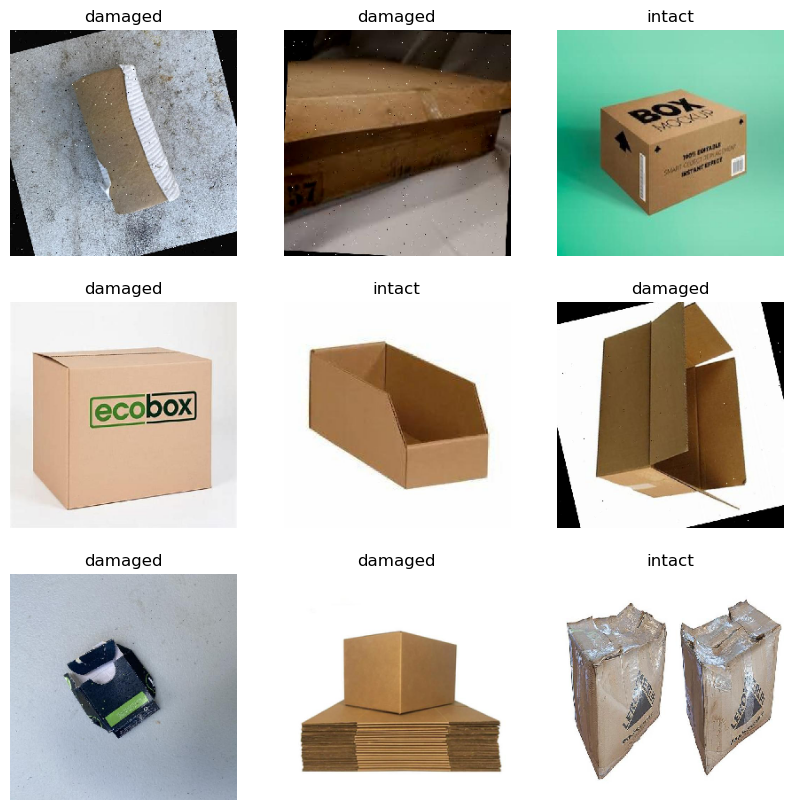

In [24]:
val_iter = iter(valid_generator)
batch = next(val_iter)

images, labels = batch

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")

# --- ADD THIS LINE ---
plt.savefig("batch_visualization.png", dpi=600, bbox_inches='tight')
# ---------------------

In [ ]:
# # Adam
# from tensorflow.keras.optimizers import Adam

# # Initialize optimizer
# opt = Adam(learning_rate=1e-3)

# # Compile model
# resnet34_model.compile(
#     optimizer=opt,
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )

# # ---- Stage 1: First 100 epochs ----
# print("\n Training for first 100 epochs...\n")
# history_1 = resnet34_model.fit(
#     train_generator,
#     validation_data=test_generator,
#     epochs=100,
#     verbose=1
# )



In [ ]:
# # ---- Stage 2: Next 100 epochs ----
# print("\n Training for next 100 epochs...\n")
# history_2 = resnet34_model.fit(
#     train_generator,
#     validation_data=test_generator,
#     epochs=200,   # total = previous (100) + new (100)
#     initial_epoch=100,
#     verbose=1
# )


In [ ]:

# # ---- Stage 3: Final 100 epochs ----
# print("\n Training for final 100 epochs...\n")
# history_3 = resnet34_model.fit(
#     train_generator,
#     validation_data=test_generator,
#     epochs=300,   # total = 300
#     initial_epoch=200,
#     verbose=1
# )


In [28]:
# acc = history_3.history['accuracy']
# val_acc = history_3.history['val_accuracy']
# loss = history_3.history['loss']
# val_loss = history_3.history['val_loss']

In [ ]:
# Step 6: Compile model with SGD optimizer and train for the first 100 epochs.
# Additional stages continue training from this checkpoint in later cells.
from tensorflow.keras.optimizers import SGD

# Initialize optimizer
opt = SGD(learning_rate=1e-3, momentum=0.9, nesterov=True)

print("\nTraining with SGD optimizer...\n")

# Compile model
resnet34_model.compile(
    optimizer=opt,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Stage 1 training
print("\nTraining for first 100 epochs...\n")
history_sgd_1 = resnet34_model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=100,
    verbose=1
)



🔹 Training with SGD optimizer...


🔹 Training for first 100 epochs...

Epoch 1/100
  8/371 [..............................] - ETA: 1:51 - loss: 3.5014 - accuracy: 0.6641

/opt/conda/lib/python3.7/site-packages/PIL/Image.py:980: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  "Palette images with Transparency expressed in bytes should be "


371/371 [==============================] - 171s 420ms/step - loss: 0.6750 - accuracy: 0.7652 - val_loss: 0.4345 - val_accuracy: 0.8204
Epoch 2/100
371/371 [==============================] - 128s 346ms/step - loss: 0.4499 - accuracy: 0.7936 - val_loss: 0.4344 - val_accuracy: 0.8188
Epoch 3/100
371/371 [==============================] - 134s 362ms/step - loss: 0.4277 - accuracy: 0.8060 - val_loss: 0.4004 - val_accuracy: 0.8370
Epoch 4/100
371/371 [==============================] - 129s 349ms/step - loss: 0.4194 - accuracy: 0.8125 - val_loss: 0.4056 - val_accuracy: 0.8331
Epoch 5/100
371/371 [==============================] - 120s 324ms/step - loss: 0.4189 - accuracy: 0.8141 - val_loss: 0.4044 - val_accuracy: 0.8299
Epoch 6/100
371/371 [==============================] - 118s 318ms/step - loss: 0.4064 - accuracy: 0.8135 - val_loss: 0.4197 - val_accuracy: 0.8133
Epoch 7/100
371/371 [==============================] - 122s 328ms/step - loss: 0.4106 - accuracy: 0.8165 - val_loss: 0.4036 - val_

In [ ]:
# Step 7: Continue training from epoch 100 to epoch 200.
print("\nTraining for next 100 epochs...\n")
history_sgd_2 = resnet34_model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=200,          # total = 100 + 100
    initial_epoch=100,   # resume from epoch 100
    verbose=1
)




🔹 Training for next 100 epochs...

Epoch 101/200
371/371 [==============================] - 143s 386ms/step - loss: 0.2726 - accuracy: 0.8825 - val_loss: 0.4060 - val_accuracy: 0.8441
Epoch 102/200
371/371 [==============================] - 144s 388ms/step - loss: 0.2673 - accuracy: 0.8864 - val_loss: 0.3941 - val_accuracy: 0.8426
Epoch 103/200
371/371 [==============================] - 142s 381ms/step - loss: 0.2668 - accuracy: 0.8842 - val_loss: 0.6330 - val_accuracy: 0.7777
Epoch 104/200
371/371 [==============================] - 133s 358ms/step - loss: 0.2669 - accuracy: 0.8888 - val_loss: 0.3336 - val_accuracy: 0.8584
Epoch 105/200
371/371 [==============================] - 132s 356ms/step - loss: 0.2564 - accuracy: 0.8913 - val_loss: 0.3195 - val_accuracy: 0.8790
Epoch 106/200
371/371 [==============================] - 135s 365ms/step - loss: 0.2666 - accuracy: 0.8852 - val_loss: 0.3221 - val_accuracy: 0.8457
Epoch 107/200
371/371 [==============================] - 147s 396ms/st

In [ ]:
# ---- Stage 3: Final 100 epochs ----
print("\n Training for final 100 epochs...\n")
history_sgd_3 = resnet34_model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=300,          # total = 200 + 100
    initial_epoch=200,   # resume from epoch 200
    verbose=1
)


🔹 Training for final 100 epochs...

Epoch 201/300
371/371 [==============================] - 118s 317ms/step - loss: 0.1710 - accuracy: 0.9291 - val_loss: 0.3925 - val_accuracy: 0.8837
Epoch 202/300
371/371 [==============================] - 117s 316ms/step - loss: 0.1545 - accuracy: 0.9365 - val_loss: 0.4798 - val_accuracy: 0.8473
Epoch 203/300
371/371 [==============================] - 117s 316ms/step - loss: 0.1640 - accuracy: 0.9299 - val_loss: 0.4062 - val_accuracy: 0.8536
Epoch 204/300
371/371 [==============================] - 119s 319ms/step - loss: 0.1524 - accuracy: 0.9396 - val_loss: 0.7518 - val_accuracy: 0.8054
Epoch 205/300
371/371 [==============================] - 118s 319ms/step - loss: 0.1570 - accuracy: 0.9340 - val_loss: 0.8648 - val_accuracy: 0.7706
Epoch 206/300
371/371 [==============================] - 118s 319ms/step - loss: 0.1623 - accuracy: 0.9315 - val_loss: 0.6569 - val_accuracy: 0.8196
Epoch 207/300
371/371 [==============================] - 118s 318ms/s

In [32]:
acc = history_sgd_3.history['accuracy']
val_acc = history_sgd_3.history['val_accuracy']
loss = history_sgd_3.history['loss']
val_loss = history_sgd_3.history['val_loss']

In [ ]:
# from tensorflow.keras.optimizers import Nadam

# # Initialize optimizer
# opt = Nadam(learning_rate=1e-3)

# print("\n Training with Nadam optimizer...\n")

# # Compile model
# resnet34_model.compile(
#     optimizer=opt,
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )

# # ---- Stage 1: First 100 epochs ----
# print("\n Training for first 100 epochs...\n")
# history_nadam_1 = resnet34_model.fit(
#     train_generator,
#     validation_data=test_generator,
#     epochs=100,
#     verbose=1
# )



In [ ]:
# # ---- Stage 2: Next 100 epochs ----
# print("\n Training for next 100 epochs...\n")
# history_nadam_2 = resnet34_model.fit(
#     train_generator,
#     validation_data=test_generator,
#     epochs=200,          # total = previous (100) + next (100)
#     initial_epoch=100,   # resume from epoch 100
#     verbose=1
# )



In [ ]:
# # ---- Stage 3: Final 100 epochs ----
# print("\n Training for final 100 epochs...\n")
# history_nadam_3 = resnet34_model.fit(
#     train_generator,
#     validation_data=test_generator,
#     epochs=300,          # total = 300
#     initial_epoch=200,   # resume from epoch 200
#     verbose=1
# )


In [36]:
# acc = history_nadam_3.history['accuracy']
# val_acc = history_nadam_3.history['val_accuracy']
# loss = history_nadam_3.history['loss']
# val_loss = history_nadam_3.history['val_loss']

In [ ]:
# from tensorflow.keras.optimizers import Adamax

# opt = Adamax(learning_rate=1e-3)

# print("\n Training with Adamax optimizer...\n")

# resnet34_model.compile(
#     optimizer=opt,
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )

# history_adamax_1 = resnet34_model.fit(
#     train_generator,
#     validation_data=test_generator,
#     epochs=300,
#     verbose=1
# )

In [ ]:
# # ---- Stage 2: Next 100 epochs ----
# print("\n Training for next 100 epochs...\n")
# history_adamax_2 = resnet34_model.fit(
#     train_generator,
#     validation_data=test_generator,
#     epochs=200,          # total = previous (100) + next (100)
#     initial_epoch=100,   # resume from epoch 100
#     verbose=1
# )


In [ ]:
# # ---- Stage 3: Final 100 epochs ----
# print("\n Training for final 100 epochs...\n")
# history_nadam_3 = resnet34_model.fit(
#     train_generator,
#     validation_data=test_generator,
#     epochs=300,          # total = 300
#     initial_epoch=200,   # resume from epoch 200
#     verbose=1
# )

Generating predictions on test set...
79/79 [==============================] - 9s 102ms/step
Plotting Confusion Matrix...


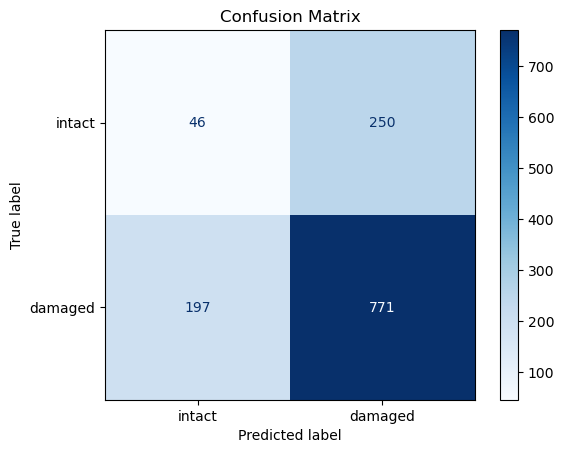

Plotting ROC Curve...


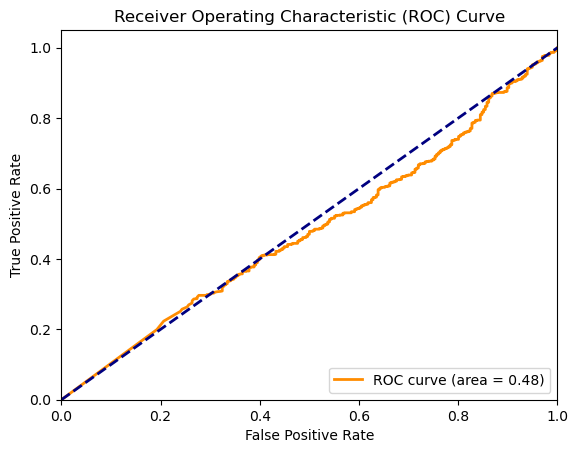

Plotting Precision-Recall (PR) Curve...


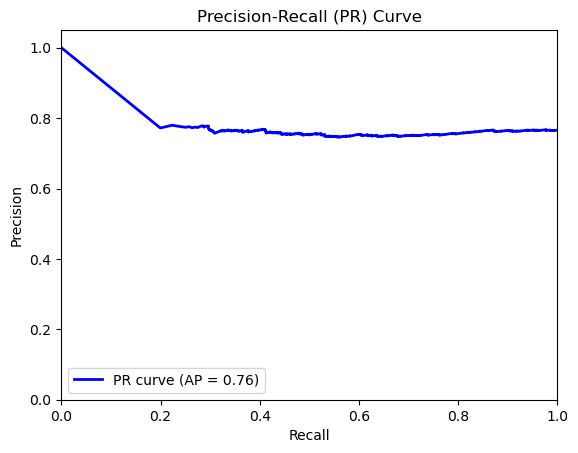

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve, average_precision_score

# Step 8: Evaluate classification quality on the test set using multiple metrics.
# We compute class predictions, confusion matrix, ROC curve, and PR curve.
print("Generating predictions on test set...")

# Reset generator to keep prediction order aligned with labels.
test_generator.reset()
y_pred_probs = resnet34_model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes
y_pred_probs_positive = y_pred_probs[:, 1]  # Probability for damaged class

# Step 8.1: Confusion matrix
print("Plotting Confusion Matrix...")
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=600, bbox_inches='tight')
plt.show()

# Step 8.2: ROC curve
print("Plotting ROC Curve...")
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs_positive)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.savefig("roc_curve.png", dpi=600, bbox_inches='tight')
plt.show()

# Step 8.3: Precision recall curve
print("Plotting Precision-Recall (PR) Curve...")
precision, recall, _ = precision_recall_curve(y_true, y_pred_probs_positive)
ap = average_precision_score(y_true, y_pred_probs_positive)

plt.figure()
plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AP = {ap:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall (PR) Curve')
plt.legend(loc="lower left")
plt.savefig("pr_curve.png", dpi=600, bbox_inches='tight')
plt.show()

In [41]:
# normalize filter values to 0-1 so we can visualize them
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)
# plot first few filters
n_filters, ix = 6, 1
for i in range(n_filters):
    # get the filter
    f = filters[:, :, :, i]
    # plot each channel separately
    for j in range(3):
        # specify subplot and turn of axis
        ax = plt.subplot(n_filters, 3, ix)
        ax.set_xticks([])
        ax.set_yticks([])
        # plot filter channel in grayscale
        plt.imshow(f[:, :, j], cmap='gray')
        ix += 1

# --- ADD THIS LINE ---
plt.savefig("filter_visualization.png", dpi=600, bbox_inches='tight')
# ---------------------

# show the figure
plt.show()

NameError: name 'filters' is not defined

In [ ]:
def visualize_feature_map(img, level, save_path=None): # Add save_path argument
    img = img_to_array(img)
    img = expand_dims(img, axis=0)
    img = img/255
    
    model = Model(inputs=resnet34_model_best.inputs, outputs=conv_layers[level].output)
    feature_maps = model.predict(img)

    square = 2
    ix = 1
    for _ in range(square):
        for _ in range(square):
            ax = pyplot.subplot(square, square, ix)
            ax.set_xticks([])
            ax.set_yticks([])

            pyplot.imshow(feature_maps[0, :, :, ix-1], cmap='gray')
            ix += 1

    # --- ADD THIS IF-STATEMENT ---
    if save_path:
        pyplot.savefig(save_path, dpi=600, bbox_inches='tight')
    # -----------------------------

    # show the figure
    pyplot.show()

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# load the best model
# resnet34_model_best = tf.keras.models.load_model('/kaggle/working/background-output/model_checkpoints/resnet34_model.h5')

resnet34_model_best = tf.keras.models.load_model('/kaggle/working/model_checkpoints/resnet34_model.h5')

In [ ]:
resnet34_model_best.evaluate(valid_generator)

In [ ]:
resnet34_model_best.evaluate(test_generator)

In [ ]:
# get the convolutional layers
conv_layers = []

for layer in resnet34_model_best.layers:
    if 'conv' in layer.name:
        filters, biases = layer.get_weights()
        conv_layers.append(layer)
        print(layer.name, filters.shape)

In [ ]:
filters, biases = conv_layers[0].get_weights()

In [ ]:
# normalize filter values to 0-1 so we can visualize them
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)
# plot first few filters
n_filters, ix = 6, 1
for i in range(n_filters):
    # get the filter
    f = filters[:, :, :, i]
    # plot each channel separately
    for j in range(3):
        # specify subplot and turn of axis
        ax = plt.subplot(n_filters, 3, ix)
        ax.set_xticks([])
        ax.set_yticks([])
        # plot filter channel in grayscale
        plt.imshow(f[:, :, j], cmap='gray')
        ix += 1
# show the figure
plt.show()

In [ ]:
from tensorflow.keras.utils import load_img
from tensorflow.keras.utils import img_to_array
from keras.models import Model
from matplotlib import pyplot
from numpy import expand_dims

In [ ]:
def visualize_feature_map(img, level):
    img = img_to_array(img)
    img = expand_dims(img, axis=0)
    img = img/255
    
    model = Model(inputs=resnet34_model_best.inputs, outputs=conv_layers[level].output)
    feature_maps = model.predict(img)

    square = 2
    ix = 1
    for _ in range(square):
        for _ in range(square):
            ax = pyplot.subplot(square, square, ix)
            ax.set_xticks([])
            ax.set_yticks([])

            pyplot.imshow(feature_maps[0, :, :, ix-1], cmap='gray')
            ix += 1

    # show the figure
    pyplot.show()

In [ ]:
from PIL import Image

Image.open(damaged_images_path + '/damagedfoodpackagingbox10.jpeg')

In [ ]:
img_damaged = load_img(damaged_images_path + '/damagedfoodpackagingbox10.jpeg', target_size=(img_width, img_height))

visualize_feature_map(img_damaged, 5)

In [ ]:
Image.open(intact_images_path + '/fooditemboxes174.jpeg')

In [ ]:
img_intact = load_img(intact_images_path + '/fooditemboxes174.jpeg', target_size=(img_width, img_height))

visualize_feature_map(img_intact, 5)

In [ ]:
x = tf.convert_to_tensor(img_damaged)
x = np.expand_dims(x, axis=0)
x = x/255

resnet34_model_best.predict(x)

In [ ]:
x = tf.co
nvert_to_tensor(img_intact)
x = np.expand_dims(x, axis=0)
x = x/255

resnet34_model_best.predict(x)